In [ ]:
!pip install scikit-survival

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.3/298.3 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.2 MB/s eta 0:00:00
  Attempting uninstall: osqp
    Found existing installation: osqp 1.0.3
    Uninstalling osqp-1.0.3:
      Successfully uninstalled osqp-1.0.3


In [ ]:
import pandas as pd

# Load your DataFrame (assuming you've already selected the needed columns)
df = pd.read_excel('/content/aibd datset (1).xlsx')
needed_cols = [
    'diagnoses.age_at_diagnosis', 'diagnoses.tumor_grade', 'diagnoses.figo_stage',
    'pathology_details.residual_tumor_measurement',
    'treatments.treatment_type', 'treatments.therapeutic_agents',
    'demographic.vital_status', 'demographic.days_to_death'
]
df = df[needed_cols]

# Identify columns to check (all except 'demographic.days_to_death')
cols_to_check = [col for col in df.columns if col != 'demographic.days_to_death']

# Remove rows where any of these columns contain "no"
mask = ~(df[cols_to_check] == "no").any(axis=1)
df_filtered = df[mask]

# (Optional) Reset index
df_filtered = df_filtered.reset_index(drop=True)

# Save the cleaned DataFrame
df_filtered.to_excel('aibd-dataset-cleaned.xlsx', index=False)


In [ ]:
import numpy as np
import pandas as pd
from sksurv.nonparametric import kaplan_meier_estimator
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("aibd-dataset-cleaned.xlsx")

# 1. Clean days_to_death
df["demographic.days_to_death"] = pd.to_numeric(
    df["demographic.days_to_death"],
    errors="coerce"  # Force "no" → NaN
)

# 2. Calculate max valid death day (ignore NaN)
max_death_day = df["demographic.days_to_death"].max()

# 3. Create time column (numeric only)
df["time"] = np.where(
    df["demographic.vital_status"] == "Dead",
    df["demographic.days_to_death"],
    max_death_day  # Alive patients censored at max death day
).astype(float)  # Explicit float conversion
study_end_day = 3000*7  # Adjust based on your study design
df["time"] = df["time"].fillna(study_end_day if np.isnan(max_death_day) else max_death_day)

df["time"] = pd.to_numeric(df["time"], errors="coerce").astype(float)

if np.isnan(df["time"]).all():
    df["time"] = 3000*7  # Study end day


# 4. Remove patients with invalid time (if any)
df = df[~df["time"].isna()]

# Convert "Dead"/"Alive" to boolean event indicator
df["event"] = (df["demographic.vital_status"] == "Dead").astype(bool)


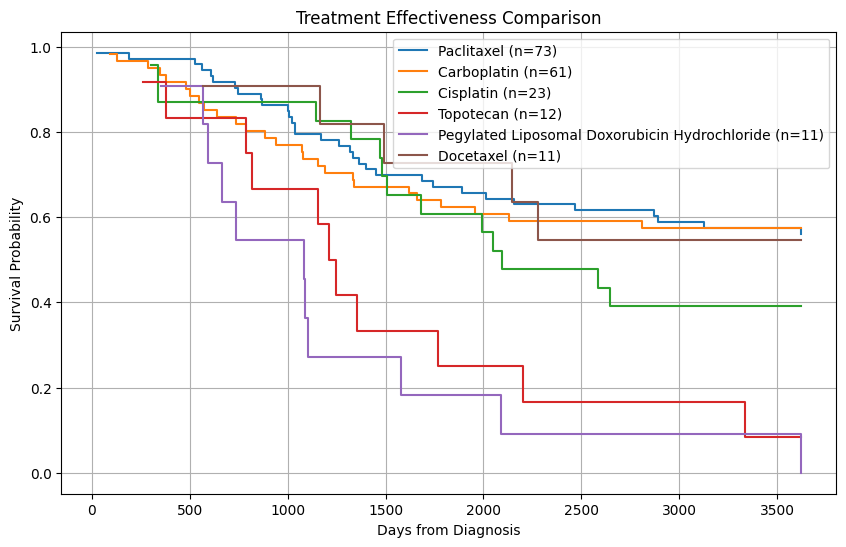

In [ ]:
# 5. Kaplan-Meier implementation

plt.figure(figsize=(10, 6))

valid_agents = df["treatments.therapeutic_agents"].value_counts()[lambda x: x >= 5].index

for agent in valid_agents:
    # Filter only the current agent's data and valid times
    agent_df = df[
        (df["treatments.therapeutic_agents"] == agent) &
        (~df["time"].isna())
    ]
    if len(agent_df) >= 1:
        time, prob = kaplan_meier_estimator(
            agent_df["event"].astype(bool),
            agent_df["time"].astype(float)
        )
        plt.step(time, prob, where="post", label=f"{agent} (n={len(agent_df)})")


plt.xlabel("Days from Diagnosis")
plt.ylabel("Survival Probability")
plt.title("Treatment Effectiveness Comparison")
plt.legend()
plt.grid(True)
plt.show()